## 1). Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

## 2). Load the dataset

In [2]:
df=pd.read_csv("/workspaces/Exploring_the_Brazi_-Real_Estate_Market_and_Building_a_model_to_predict_property_prices-/notebooks/brasil-real-estate-clean.csv")
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 22844 entries, 0 to 22843
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  22844 non-null  str    
 1   state          22844 non-null  str    
 2   region         22844 non-null  str    
 3   lat            22844 non-null  float64
 4   lon            22844 non-null  float64
 5   area_m2        22844 non-null  int64  
 6   price_usd      22844 non-null  float64
dtypes: float64(3), int64(1), str(3)
memory usage: 1.2 MB


,property_type,state,region,lat,lon,area_m2,price_usd
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72,82844.596
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136,169681.706
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75,59887.656
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187,169681.706
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80,92825.872


## 3). Univariate Analyses

### i). Property_type

In [3]:
df.property_type.value_counts()
df.property_type.value_counts(normalize=True)*100

property_type
apartment    80.822098
house        19.177902
Name: proportion, dtype: float64

#### Insights

- The dataset is of two property types; apartment and house
- Apartments take the lions share of the dataset with a whooping 80.8 percent of the total entries

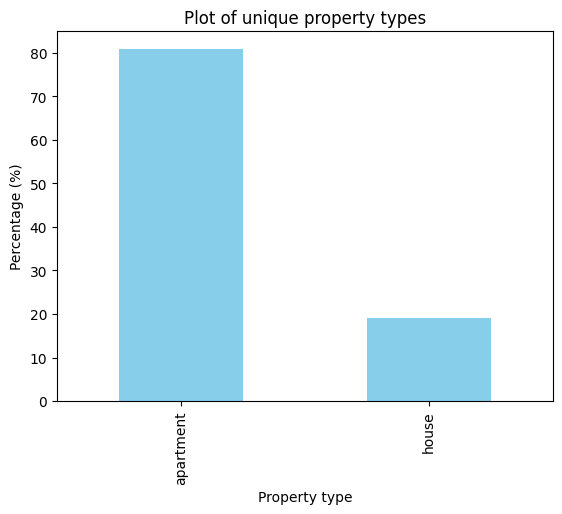

In [4]:
(df.property_type.value_counts(normalize=True)*100).plot(kind='bar', color="skyblue")
plt.title("Plot of unique property types")
plt.ylabel("Percentage (%)")
plt.xlabel("Property type");

#### ii). State

In [5]:
df.state.value_counts(normalize=True)

state
Minas Gerais           0.117317
São Paulo              0.116267
Rio Grande do Sul      0.115698
Rio de Janeiro         0.115654
Santa Catarina         0.115304
Paraná                 0.111364
Bahia                  0.089520
Ceará                  0.068902
Distrito Federal       0.032043
Espírito Santo         0.024295
Goiás                  0.024295
Pernambuco             0.017773
Rio Grande do Norte    0.013220
Pará                   0.013089
Paraíba                0.010944
Maranhão               0.004421
Mato Grosso            0.003765
Sergipe                0.002977
Piauí                  0.001051
Alagoas                0.001051
Mato Grosso do Sul     0.000613
Rondônia               0.000219
Amazonas               0.000131
Tocantins              0.000044
Amapá                  0.000044
Name: proportion, dtype: float64

#### Insights.
- The dataset consists of 25 states in Brazil.
- Minas Gerais, Sao Paolo, Rio Grande do Sul, Rio De Janeiro, Santa Catarina and Parana states dominate the dataset


#### iii) Region

In [6]:
df.region.value_counts(normalize=True)*100

region
Southeast       37.353353
South           34.236561
Northeast       20.985817
Central-West     6.071616
North            1.352653
Name: proportion, dtype: float64

#### Insights.
- The dataset consists of 5 regions with Southeast, South and Northeast regions being fairly represented. 
- Central-West and North regions are the least represented

#### iv). Area

In [7]:
df.area_m2.describe()

count    22844.000000
mean       115.020224
std         47.742932
min         53.000000
25%         76.000000
50%        103.000000
75%        142.000000
max        252.000000
Name: area_m2, dtype: float64

In [8]:
Coefficient_of_variation=47.7/115*100
# 10% - 30% Low to moderate variation
# 30% - 50% Moderate to high
# > 50 % Very high

#### Insights.
- The mean area_m2 is approximately 115 m2, while the median is 103 m2. The median and mean are relatively close suggesting the distribution is moderately symmetric.
- The maximum value (252)  is significantly higher than the upper quartile suggesting the presence of high-end outliers.
- 25% of the area_m2 is below 76 m2, 50% is below 103 m2 and 75% is below 142 m_2. These metrics show that most properties fall within a relatively narrow range.
- The standard deviation (47.7) > 41% points out to a moderate to high variability but fairly dispersed. It also means that most apartments tend to differ from the average by about 48 m2 up or down



np.float64(0.9296026229545704)

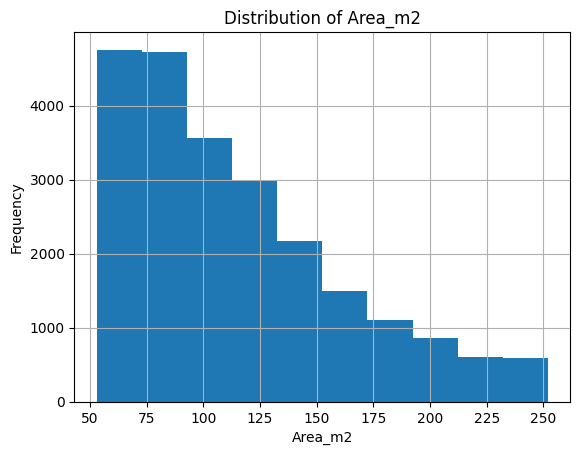

In [9]:
df.area_m2.plot(kind="hist")
plt.xlabel("Area_m2")
plt.title("Distribution of Area_m2")
plt.grid()
df.area_m2.skew()

- There is a moderate right skew in the distribution of area_m2. A large number of property areas are concentrated at the lower end. This histogram cinfirms the presence of outliers

#### v). Price

In [10]:
df.price_usd.describe()

count     22844.000000
mean     157687.256710
std       87710.730019
min       47910.126000
25%       92679.270000
50%      133749.106000
75%      199625.534000
max      524246.390000
Name: price_usd, dtype: float64

#### Insights
- The mean price in dollars for properties in Brazil is 157,687 while the median is 133,749. This indifference suggests a possible skewed distribution, thus the median would be a good representation of the average house prices.
- The maximum property price 524,246 is way above the 75th percentile 199,625 indicating presence of outliers.
- 25 percent of properties are priced below 92,679 , 50 percent are priced below 133,749 while 75 percent are priced below 199,625

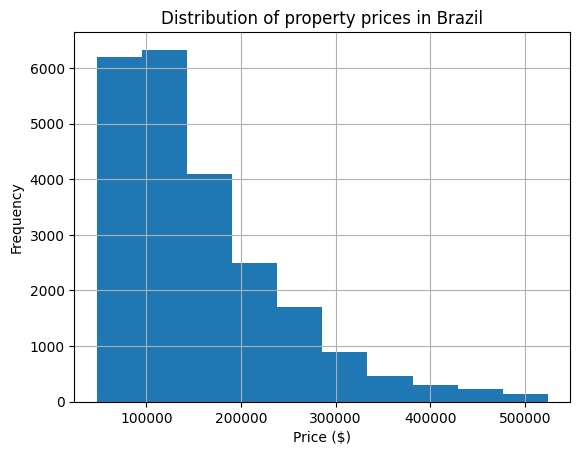

In [11]:
df.price_usd.hist()
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.title("Distribution of property prices in Brazil");

## 4). Bivariate Analyses

### a). Features vs target Analysis

### i). How does property prices vary across different states


In [13]:
df.groupby("state")["price_usd"].describe()

,count,mean,std,min,25%,50%,75%,max
state,,,,,,,,
Alagoas,24.0,180356.561250,101627.398268,75727.070,109699.8025,158703.265,199718.9150,466625.470
Amapá,1.0,148349.220000,NaN,148349.220,148349.2200,148349.220,148349.2200,148349.220
Amazonas,3.0,148744.510000,89702.349710,78012.850,98296.1950,118579.540,184110.3400,249641.140
Bahia,2045.0,183215.884689,97305.312740,74892.340,109217.9900,152905.190,229357.7900,524246.390
Ceará,1574.0,192614.281423,95745.591367,74892.340,121700.0500,167362.535,234038.5600,520411.900
Distrito Federal,732.0,186818.838306,99594.160249,74892.340,109217.9900,162266.740,230267.8825,518005.360
Espírito Santo,555.0,149688.857730,76103.623057,74892.340,96735.9400,124820.570,177869.3100,499282.280
Goiás,555.0,171347.391982,91672.066928,74892.340,99856.4500,140423.140,225347.9300,499282.280
Maranhão,101.0,167956.091683,97800.882355,74892.340,99856.4500,130094.860,187624.3500,497409.970


### Insights
> Highest average prices are concentrated in states like: Minas Gerais (~200K), Bahia (~183K), Ceará (~193K), Distrito Federal (~187K), Pará (~183K)
- These states are likely economically stronger and show a relatively high cost of property compared to the national spread.

> Lower-priced states form a distinct group.
- Some states consistently show much lower average property prices. I.e, Piauí (~98K), Rio Grande do Norte (~103K), Rio Grande do Sul (~111K), Sergipe (~90K), Tocantins (~58K, very limited data), Rondônia (~71K)
- This suggests a clear low-cost property cluster, likely driven by regional economic differences.

> There is also strong imbalance in data representation.
- Some states have very small sample sizes, which affects reliability: Amapá → 1 observation, Tocantins → 1 observation, Rondônia → 5 observations, Amazonas → 3 observations

> There is high variability within most states.
- Across nearly all states, Standard deviation is large (often ~40K–100K+), Interquartile ranges are wide
- This indicates property prices within states are highly diverse, not uniform. Meaning each state contains both mid-range and expensive properties

> There is a strong overlap in price ranges across states.Even though means differ, many states share similar ranges:
- Minimum values across states are often similar (~47K–75K)
- Maximum values often exceed 300K–500K in many states
This points to the fact that expensive properties exist in almost every state, but their frequency differs.

> Higher average prices tend to appear in states that are economically developed, urbanized states and states with large metropolitan centers
- This suggests that price level is influenced more by urban density and economic activity than just geographic state.

> Overally.

The Brazilian real estate market shows strong geographic segmentation, with significant differences in average property prices across states. However, within-state variability is high, and sample imbalance suggests that state-level averages should be interpreted alongside distribution spread and sample size.

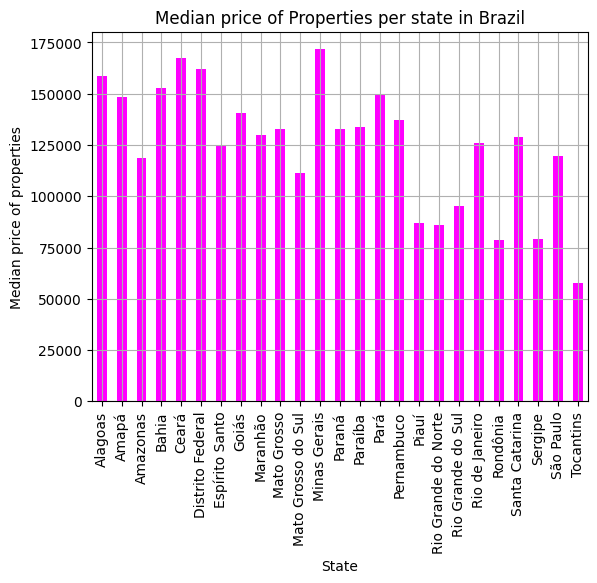

In [14]:
df.groupby('state')["price_usd"].median().plot(kind="bar",  color="magenta")
plt.xlabel("State")
plt.ylabel("Median price of properties")
plt.title("Median price of Properties per state in Brazil")
plt.grid();

#### ii) What is the relationship between property area and price

In [18]:
price_per_m2=df["price_usd"].sum()/df["area_m2"].sum()
price_per_m2

np.float64(1370.9524381824394)

#### 
The average price of properties per square meters is 1370 dollars

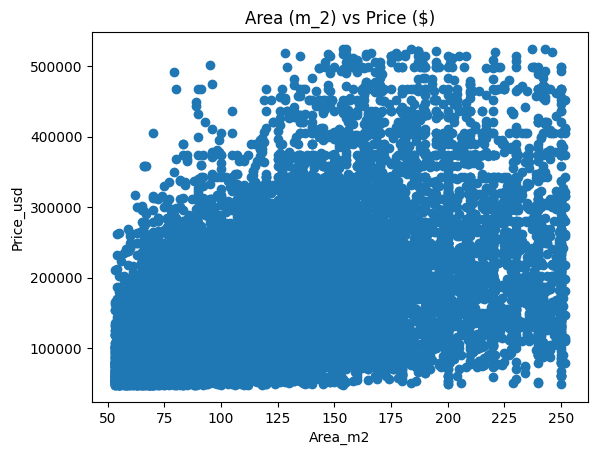

In [22]:
plt.scatter(y=df["price_usd"], x=df["area_m2"])
plt.xlabel("Area_m2")
plt.ylabel("Price_usd")
plt.title("Area (m_2) vs Price ($)");

#### Insights
- The scatter plot reveals a positive relationship between property area and price, indicating that larger properties generally command higher prices.
- However the relationship is relatively weak as properties with similar areas often exhibit substantial differences in price. This imply that while area is an important predictor of price, additional factors such as location and property type are required to explain the difference in property values

In [26]:
correlation=df["area_m2"].corr(df["price_usd"])
correlation

np.float64(0.5345419226789392)

There is a moderate positive correlation (0.53) between property price and area

#### iii) How does property prices vary across different regions

In [27]:
df.groupby("region")['price_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
Central-West,1387.0,178596.283663,95873.064365,74892.340,104160.090,149892.130,221556.510,518005.36
North,309.0,180550.097307,93702.198661,50479.760,118579.540,147584.400,218435.990,511140.23
Northeast,4794.0,175629.800482,95935.141100,47910.126,105023.621,149719.146,218435.990,524246.39
South,7821.0,139920.867394,77936.010204,47910.126,83643.700,116103.460,177628.400,517212.75
Southeast,8533.0,159664.162589,86518.938142,47910.126,94822.124,138880.120,201919.064,524246.39


### Insights
The Brazilian real estate market exhibits meaningful regional variation in property prices. The North, Central-West, and Northeast regions have the highest average prices, while the South is the most affordable. Property prices in all regions are positively skewed and display substantial variability, indicating that regional location influences price but does not fully determine it. The presence of high-value properties across all regions suggests that local market conditions and property-specific characteristics likely play an important role in explaining price differences.

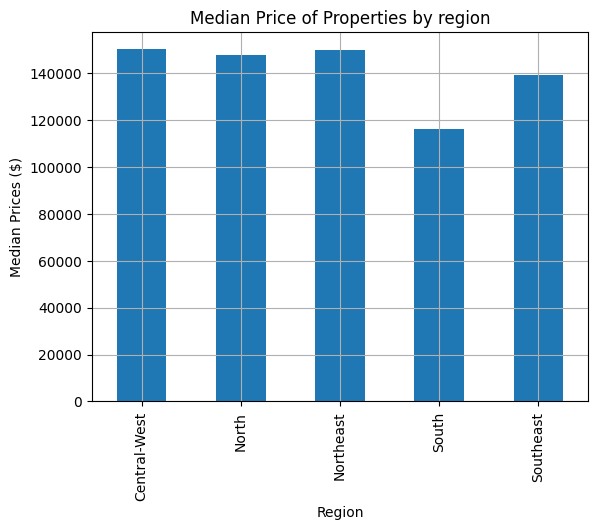

In [33]:
df.groupby("region")["price_usd"].median().plot(kind="bar")
plt.grid()
plt.xlabel("Region")
plt.ylabel("Median Prices ($)")
plt.title("Median Price of Properties by region");

#### iv) How does prices range with different property type

In [34]:
df.groupby("property_type")["price_usd"].describe()

,count,mean,std,min,25%,50%,75%,max
property_type,,,,,,,,
apartment,18463.0,162040.983525,90366.839914,47910.126,93744.08,137304.964,205163.81,524246.39
house,4381.0,139339.195037,72695.249340,47910.126,87374.39,119775.318,171628.28,524246.39


#### Insights
Property type appears to be an important predictor of price in the Brazilian real estate market. Apartments are generally more expensive than houses, exhibiting both higher average and median prices. Apartment prices also show greater variability, reflecting a broader range of market segments from standard to luxury units. Although luxury properties exist in both categories, apartments tend to command a higher overall market value and dominate the dataset in terms of representation

Text(0.5, 1.0, 'Median price per Property types')

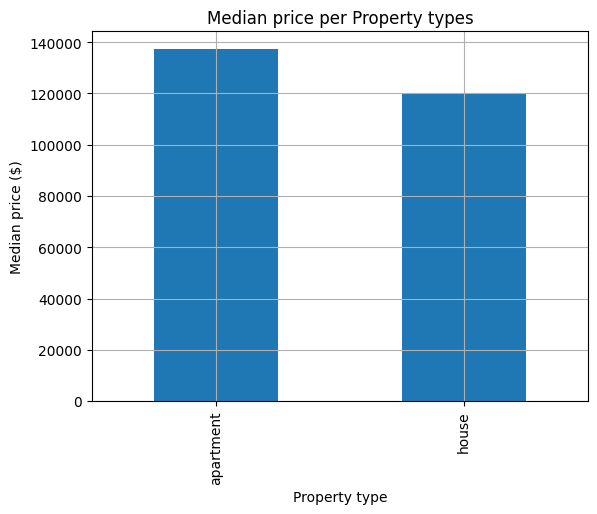

In [35]:
df.groupby("property_type")["price_usd"].median().plot(kind="bar")
plt.grid()
plt.xlabel("Property type")
plt.ylabel("Median price ($)")
plt.title("Median price per Property types")

#### v). How does property prices differ across different geographic locations

In [47]:


fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="lon",
    color="price_usd",
    size="price_usd",
    zoom=5,
    mapbox_style="open-street-map"
)

fig.show()

/tmp/ipykernel_2800/2790207630.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(
